# Notebook 1: Data quality and cleaning

## 1. Project Overview

This project analyzes a dataset of 614 loan applications to understand the factors influencing loan approval and to develop a framework for assessing credit risk. The analysis includes exploratory data analysis, feature engineering, and predictive modeling using Logistic Regression and XGBoost.

The project is divided into three parts:

1. Data Quality and Cleaning  
2. Feature Engineering and Risk Analysis  
3. Credit Risk Modeling  

The dataset used in this project was obtained from: https://www.kaggle.com/datasets/burak3ergun/loan-data-set/data and contains demographic and financial information for 614 loan applicants.

### Approach

This notebook focuses on **Exploratory Data Analysis (EDA)** and initial data preparation. The goal is to understand the dataset, identify potential data quality issues, and prepare the data for further analysis.

The following steps are performed:

- Inspect and clean the dataset
- Identify and handle missing values
- Visualize distributions of categorical and numeric variables
- Perform univariate and bivariate analysis comparing variables with loan approval
- Evaluate the need for derived features and data transformation

### Business Context

Financial institutions evaluate loan applications to determine whether borrowers are likely to repay their loans. Poor lending decisions can lead to increased default rates and financial losses.

Credit risk modeling helps lenders assess the probability that a borrower will repay a loan. By analyzing historical loan application data, predictive models can identify patterns associated with loan approval and repayment behavior.

In this project, the objective is to explore borrower characteristics and financial indicators that influence loan approval decisions and to develop a model that estimates the likelihood of loan approval.

### References

This project was developed with guidance from a tutorial series by Muhammad Faizin Zen on Medium, which explains the process of building a credit scoring model step-by-step. The articles were used as references for understanding typical preprocessing steps and modeling approaches used in credit risk analysis.

To better understand credit risk datasets and typical preprocessing approaches used in credit scoring, the following resources were used:

Articles by Muhammad Faizin Zen:

- Building a Credit Score Model: Understanding the Business Context and Dataset (2025)  
- Building a Credit Score Model: Handling Missing Values and Outliers (2025)
- Building a Credit Score Model: Feature Engineering and Encoding (2025)

Example on Kaggle by Louis Deconinck
- Credit Risk Modelling: Probability of Default (2023)

### Table of Contents

1. Project Overview  
2. Packages Used  
3. Downloading and Initial Inspection  
4. Handling Missing Values  
   - 4.1 Visualization of Missing Values  
   - 4.2 Identifying Missingness Mechanisms  
   - 4.3 Imputation Using Median/Mode  

5. Exploratory Data Analysis (EDA)  
   - 5.1 Target Variable  
   - 5.2 Univariate Analysis  
        - 5.2.1 Categorical Variables  
        - 5.2.2 Numeric Variables  
   - 5.3 Bivariate Analysis  
        - 5.3.1 Categorical Features vs Loan Status  
        - 5.3.2 Numeric Features vs Loan Status  

6. Outlier Analysis  
   - 6.1 Categorical Data  
   - 6.2 Numeric Data  
   - 6.2.1 Winsorization and Transformation  

7. Saving the Cleaned Dataset
8. Conclusions of Notebook 1

<h1 style="text-align: center;">Variables in Data explained</h1>

| Column | Description | Datatype |
|------|-------------|------|
| **Loan_ID** | Unique identifier for each loan application | String |
| **Gender** | Gender of the applicant | Binary |
| **Married** | Marital status of the applicant | Binary |
| **Dependents** | Number of dependents the applicant has | Categorical |
| **Education** | Education level of the applicant (Graduate or Not Graduate) | Binary |
| **Self_Employed** | Whether the applicant is self-employed | Binary |
| **ApplicantIncome** | Income of the applicant | Numeric |
| **CoapplicantIncome** | Income of the co-applicant (if any) | Numeric |
| **LoanAmount** | Amount of the loan applied for | Numeric |
| **Loan_Amount_Term** | Term of the loan in months | Categorical |
| **Credit_History** | Credit history of the applicant (1 = good credit history, 0 = poor credit history) | Binary |
| **Property_Area** | Area where the property is located (Urban, Rural, Semiurban) | Categorical |
| **Loan_Status** | Whether the loan was approved (Y = approved, N = not approved) | Binary |

# 2. Packages used

In [1]:
import pandas as pd
import missingno as msno
import numpy as np
from scipy.stats import pointbiserialr, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Downloading and Initial inspection

In [2]:
df = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\raw_data\loan_data_set.csv")
pd.set_option("display.max_colwidth", None)
#New DataFrame for making final changes in df. loan_df is used to look at original data
df = df.rename(columns={"ApplicantIncome": "Applicant_Income", "CoapplicantIncome": "Coapplicant_Income", "LoanAmount": "Loan_Amount"})
print("Size of dataframe:",df.shape)
df.head()

Size of dataframe: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.describe()

,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
#Looking at datatypes and missing values
print(df.info()," \n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             614 non-null    object 
 1   Gender              601 non-null    object 
 2   Married             611 non-null    object 
 3   Dependents          599 non-null    object 
 4   Education           614 non-null    object 
 5   Self_Employed       582 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         592 non-null    float64
 9   Loan_Amount_Term    600 non-null    float64
 10  Credit_History      564 non-null    float64
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None  



From this we can see majority of the data is in the wrong kind of form and needs to be transformed the following:
 1. Loan_ID in a running number so it should be string
 2. Gender, Dependents, Education,Self_Employed, Loan_Amount_Term, Credit_History, Property_Area, and Loan_Status are all categorical values and can be changed to binary (0/1) values to ease analysis.
 3. Applicant_Income, Coapplicant_Income, and Loan_Amount are all  so called continues measurements and so should be numeric

In [5]:
#Making datatypes uniform across different types of values
df["Loan_ID"] = df["Loan_ID"].astype("string")
df["Applicant_Income"] = df["Applicant_Income"].astype("float64")
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype("object")
df["Credit_History"] = df["Credit_History"].astype("object")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             614 non-null    string 
 1   Gender              601 non-null    object 
 2   Married             611 non-null    object 
 3   Dependents          599 non-null    object 
 4   Education           614 non-null    object 
 5   Self_Employed       582 non-null    object 
 6   Applicant_Income    614 non-null    float64
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         592 non-null    float64
 9   Loan_Amount_Term    600 non-null    object 
 10  Credit_History      564 non-null    object 
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(3), object(9), string(1)
memory usage: 62.5+ KB


### Section 3. Conclusion

Key observations from this section:
- The datatypes of several features were corrected:

   - Applicant_Income (int64 → float64)
   - Loan_Amount_Term (float64 → object)
   - Credit_History (float64 → object)
   
- The dataset contains a significant amount of missing data that requires appropriate handling before modeling.
- Income and loan-related features have extremely high maximum values relative to the 75th percentile, indicating the presence of outliers that need to be addressed.

Next steps:

- Handle missing values carefully (median/mode or predictive imputation where appropriate).
- Apply transformations and analyse outliers to income and loan features.

# 4.	Handling missing values


At this point only missing data will be looked since plotting data with mssing values could give wrong conclusions**

In [6]:
#Precentage of missing values
print("Precentage of missing data", ((df.isna().sum().sum())/len(df))*100, "% \n")
#also check duplication of rows
print("Duplicated rows:", len(df)-len(df.drop_duplicates()))

Precentage of missing data 24.267100977198698 % 

Duplicated rows: 0


## 4.1.	Visualization of missing values

Percentage of missing data 22.149837133550488 %



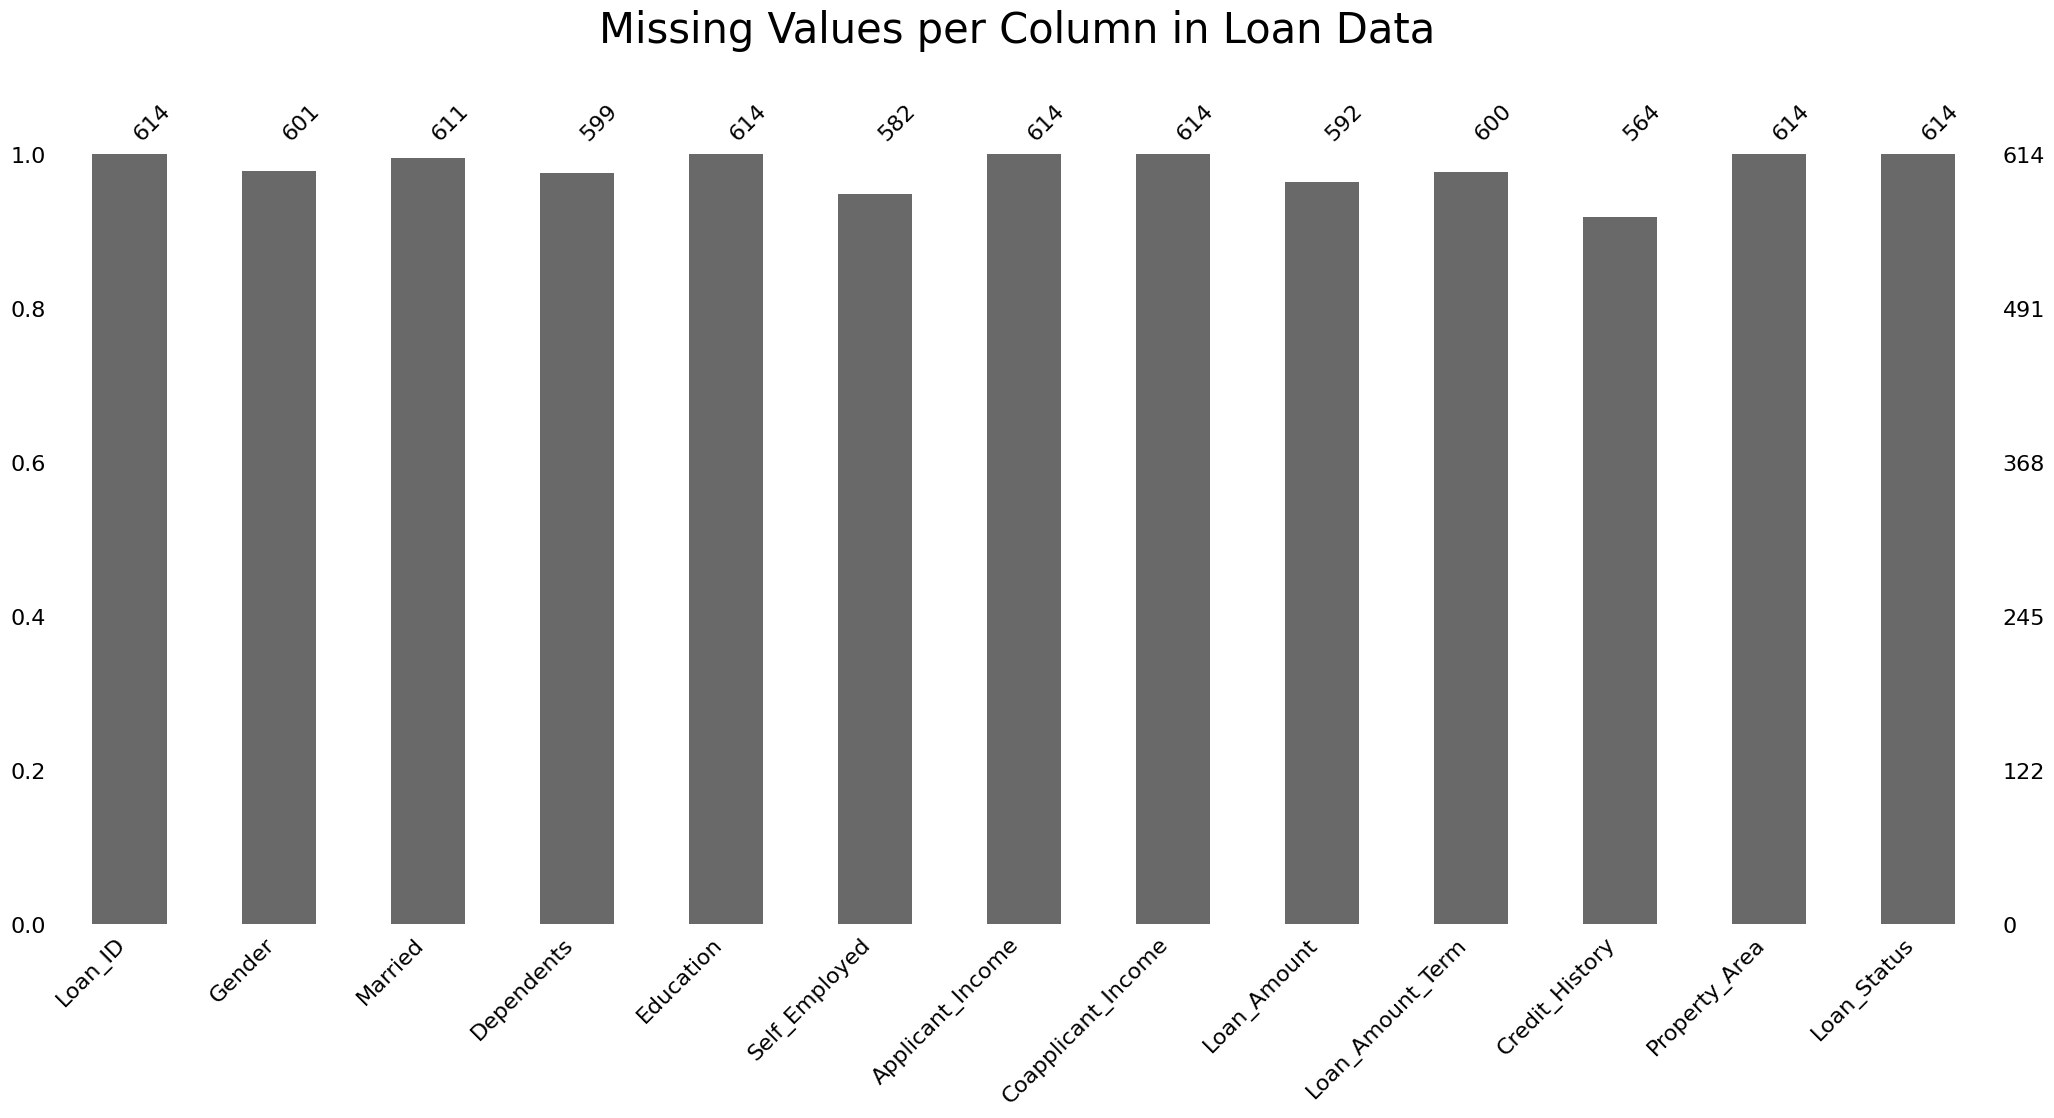

In [7]:
#Calculation of data that could be removed
print("Percentage of missing data", ((df.isna().sum().sum()-13)/len(df))*100, "%\n")

#Visualizing amount of data missing
msno.bar(df)
plt.title("Missing Values per Column in Loan Data \n",fontsize=30) 
plt.show()

<Figure size 1000x400 with 0 Axes>

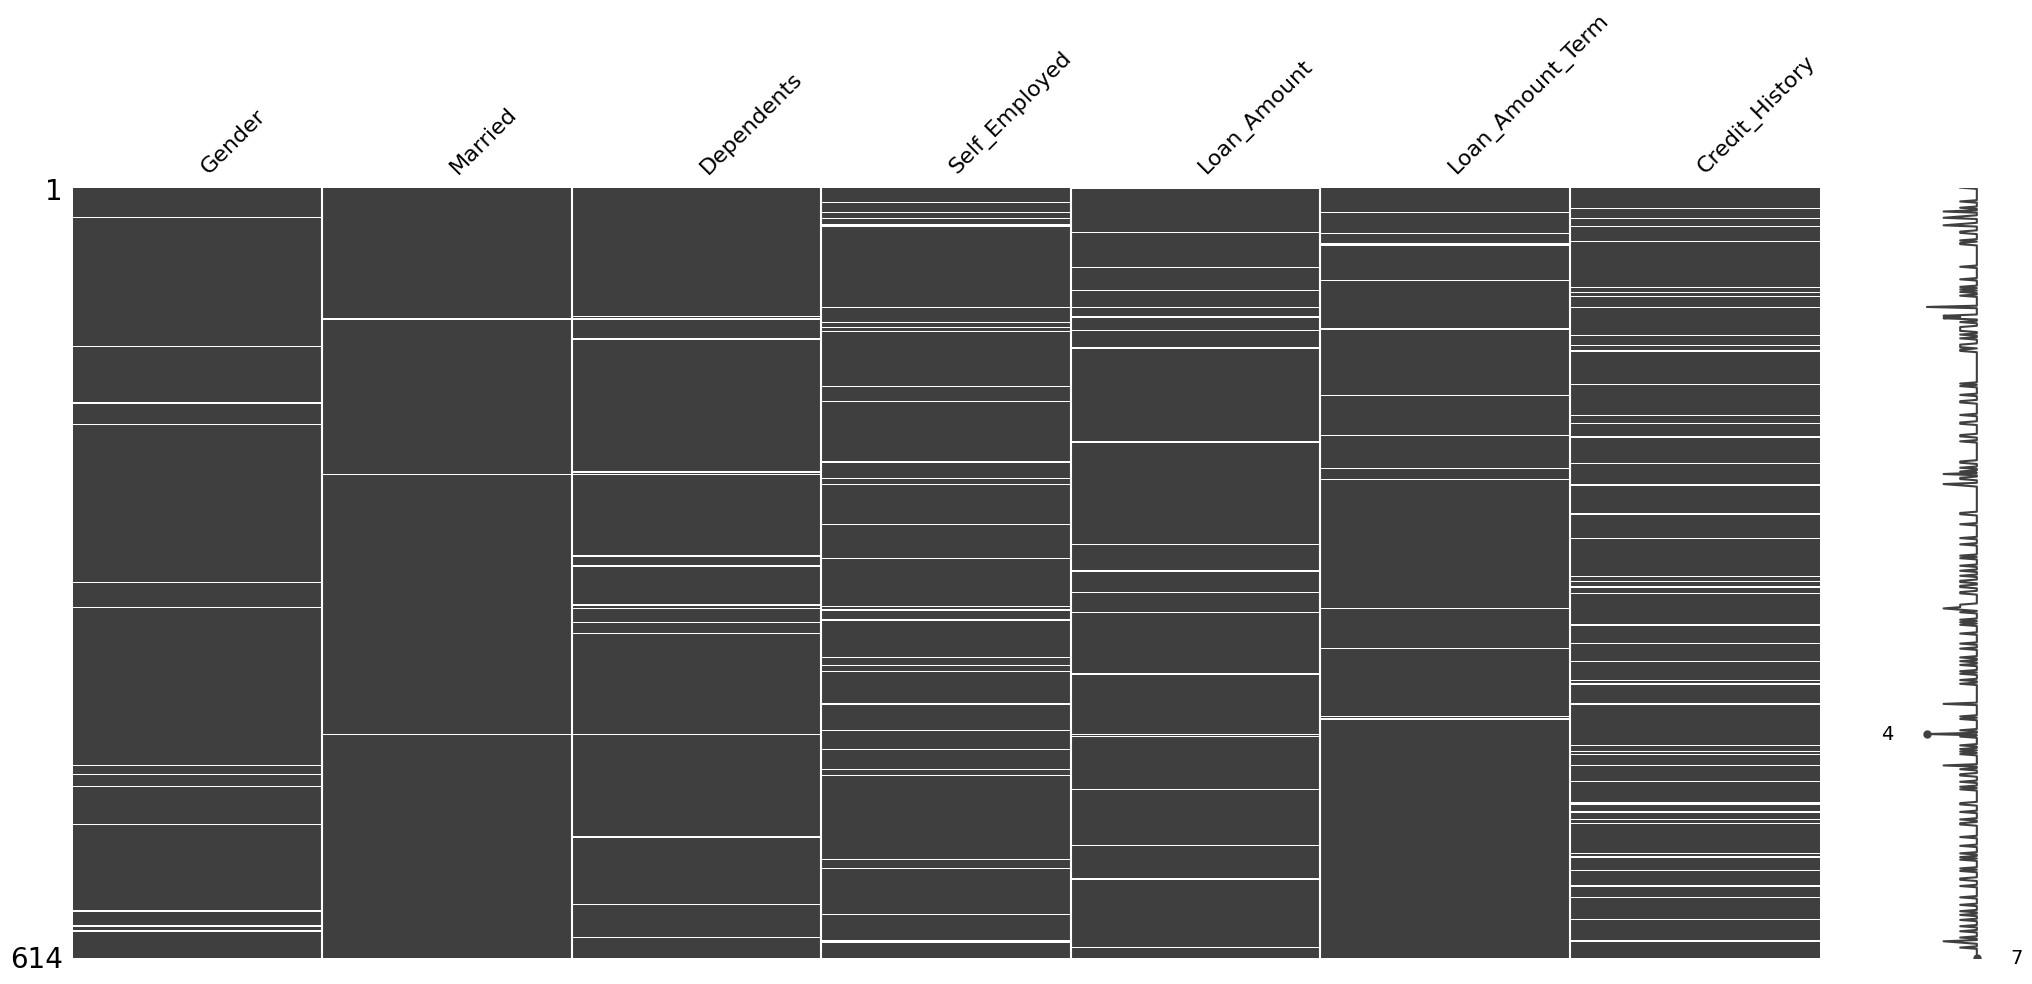

In [8]:
#Shows where missing data is in the df.
columns_missing = df.columns[df.isna().any()]
plt.figure(figsize=(10,4))
msno.matrix(df[columns_missing])
plt.show()

There are few visual correlation, like missing data for people how have not told about maritial status and telling about dependants.  

## 4.2.	Identifying missing values

Approximately 24% of the data is missing, meaning that removing rows would significantly reduce the dataset. Therefore, row deletion was avoided and an imputation strategy was required.

Before selecting the imputation method, the missingness mechanism was evaluated to determine whether the data were Missing Completely at Random (MCAR) or Missing at Random (MAR). Detecting Missing Not at Random (MNAR) patterns typically requires domain knowledge of the data-generating process and was therefore not considered. The maximum missing rate per feature was ~8%, indicating relatively limited missingness.

To assess the mechanism, a binary missingness indicator (1 = missing, 0 = observed) was created for each variable containing missing values. Associations between the indicator and other variables were tested using:

- Point-biserial correlation for numeric variables

- Chi-squared tests for categorical variables

A Bonferroni correction was applied to account for multiple hypothesis testing.

In [9]:
def estimation_missing_values(df, alpha=0.05):
    rows = []
    n_rows = len(df)
    
    #Defining which columns are numeric values, and categorical values, and columns with missing values
    missing_cols = df.columns[df.isna().any()]
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

    #Going through missing columns and turning values in columns binary
    for col in missing_cols:
        y = df[col].isna().astype(int)
        prediction = []
        
        # Calculation of missing values per colunm
        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / n_rows)*100
        
        # Number of statistical tests for Bonferroni correction
        n_tests = (len(df.columns) - 1)
        alpha_corr = alpha / n_tests if n_tests > 0 else alpha

        # Going through numeric columns with missing values and filling missing values with median values
        for num in numeric_cols:
            if num == col:
                continue
            x = df[num]
            #Filtering data so I can actually see the meaning of removing the value
            filt = (~y.isna()) & (~x.isna())
            x_filt, y_filt = x[filt], y[filt]
            if len(np.unique(y_filt)) > 1 and len(np.unique(x_filt)) > 1:
                try:
                    #Calculating p-value for numeric data
                    r, p = pointbiserialr(y_filt, x_filt)
                    if p < alpha_corr:
                        prediction.append(f"{num} (num, p={p:.3f})")
                except Exception:
                    continue

        # Going through categorical columns with missing values and filling missing values with mode value
        for cat in categorical_cols:
            if cat == col:
                continue
            x = df[cat]
            filt = (~y.isna()) & (~x.isna())
            x_filt, y_filt = x[filt], y[filt]
            table = pd.crosstab(x_filt, y_filt)
            if table.shape[0] > 1 and table.shape[1] > 1:
                #Calculating chi squered for categorical data
                try:
                    _, p, _, _ = chi2_contingency(table)
                    if p < alpha_corr:
                        prediction.append(f"{cat} (cat, p={p:.3f})")
                except Exception:
                    continue

        # Determine missingness mechanism
        if prediction:
            mech = "Evidence against MCAR (possible MAR)"
        else:
            mech = "Consistent with MCAR"

        rows.append({
            "Column": col,
            "Missing Count": missing_count,
            "Missing %": round(missing_pct, 2),
            "Missingness Mechanism": mech,
            "Significant Predictors": ", ".join(prediction) if prediction else "-"
        })

    return pd.DataFrame(rows)

estimation_missing_values(df)

,Column,Missing Count,Missing %,Missingness Mechanism,Significant Predictors
0,Gender,13,2.12,Evidence against MCAR (possible MAR),"Applicant_Income (num, p=0.003)"
1,Married,3,0.49,Evidence against MCAR (possible MAR),"Loan_Amount_Term (cat, p=0.000)"
2,Dependents,15,2.44,Consistent with MCAR,-
3,Self_Employed,32,5.21,Consistent with MCAR,-
4,Loan_Amount,22,3.58,Consistent with MCAR,-
5,Loan_Amount_Term,14,2.28,Consistent with MCAR,-
6,Credit_History,50,8.14,Consistent with MCAR,-


Most missing values appear to be MCAR, and since the proportion per variable is low (mostly 0.5–5%), simple imputation was applied: median for numeric variables and mode for categorical variables. Rows were not dropped despite ~ 24% missing data overall. Credit_History has the most missing values (~ 8%); while predictive imputation could have been used, it was not applied here. This should be noted, as Credit_History is usually an important predictor of loan approval, so its absence could make the model overly accepting of loans.

## 4.3.	Replacing missing values with median/mode

In [10]:
# fill missing values
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

#At this step I want to easily demonstrate plots of graphs and skewness. If Loan_Amount_Term and Credit_Hisotry were
#numeic, it would calculate skewness for them as well and not give value counts which I want to see
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype("object")
df["Credit_History"] = df["Credit_History"].astype("object")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             614 non-null    string 
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    object 
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    float64
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    float64
 9   Loan_Amount_Term    614 non-null    object 
 10  Credit_History      614 non-null    object 
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(3), object(9), string(1)
memory usage: 62.5+ KB


### Section 4. Conclusion
Key observations from this analysis:

- Approximately 24% of the dataset contains missing values, with missingness per feature ranging from 0.5% to 8%. Visualization using msno.matrix suggested that the missing values appear largely random.
- Statistical tests were conducted to evaluate the missingness mechanism. Point-biserial correlation (for numeric variables) and chi-square tests (for categorical variables), with Bonferroni correction, indicated some associations between missingness and other variables, particularly Gender with Applicant_Income and Married with Loan_Amount_Term.
- Since the proportion of missing data per feature was relatively small (maximum ~ 8%), and dropping rows would significantly reduce the dataset size, missing values were imputed using median for numeric variables and mode for categorical variables.

# 5.	Exploratory Data Analysis (EDA)


Before implementing new features in the dataset, their usefulness will first be evaluated. Four new features will be created based on financial relationships commonly used in credit risk analysis:

- Total_Income = ApplicantIncome + CoapplicantIncome
<br>Approximates the total household repayment capacity.

- DTI (Debt-to-Income Ratio) = LoanAmount / Total_Income
<br>A common metric used by banks to assess the repayment burden relative to income.

- Debt_Ratio = LoanAmount / ApplicantIncome
<br>Highlights the financial pressure on the primary applicant.

- Has_Coapplicant = Coapplicant_Income > 0
<br>A binary feature indicating whether an applicant has a coapplicant.
This feature was created because Coapplicant_Income is highly positively skewed due to applicants without a coapplicant being recorded as having an income of 0. Additionally, logistic regression models often interpret binary indicators more effectively than highly skewed numeric variables.

To evaluate these features, a copy of the dataset with imputed missing values will be used. The new features will only be added to the final dataset after performing a train-test split in order to prevent data leakage.

In [12]:
df_trial = df.copy()

#Feature Engineering of potential features for estimation of importance
df_trial["Total_Income"] = df_trial["Applicant_Income"] + df_trial["Coapplicant_Income"]
df_trial["DTI"] = df_trial["Total_Income"]/df_trial["Loan_Amount"]
df_trial["Dept_Ratio"] = df_trial["Applicant_Income"]/df_trial["Loan_Amount"]
df_trial["Has_Coapplicant"] = (df_trial["Coapplicant_Income"] > 0).map({True: "Yes", False: "No"})

#Picking numeric and categorical features
numeric_col = df_trial.select_dtypes(include="number").columns.tolist()
categorical_col = df_trial.select_dtypes(include=["object"]).columns.tolist()

## 5.1. Target variable

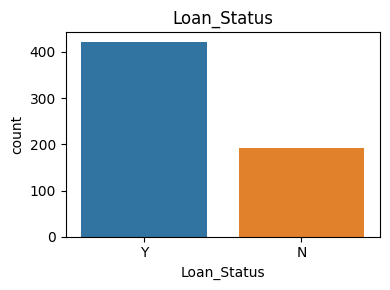

Number of excepted and not excepted loans:
 Y    68.729642
N    31.270358
Name: Loan_Status, dtype: float64


In [13]:
plt.figure(figsize=(4,3))

sns.countplot(data=df, x="Loan_Status")
plt.title("Loan_Status")

plt.tight_layout()
plt.show()
print("Number of excepted and not excepted loans:\n", 
      ((df["Loan_Status"].value_counts())/(df["Loan_Status"].value_counts().sum()))*100)

## 5.2. Univariete EDA

### 5.2.1. Categorical Data


Univariate analysis of categorical variables helps identify rare categories and potential class imbalances within the dataset. This analysis provides insight into which groups may carry predictive information related to loan approval and helps determine which features could be useful for the modeling process.

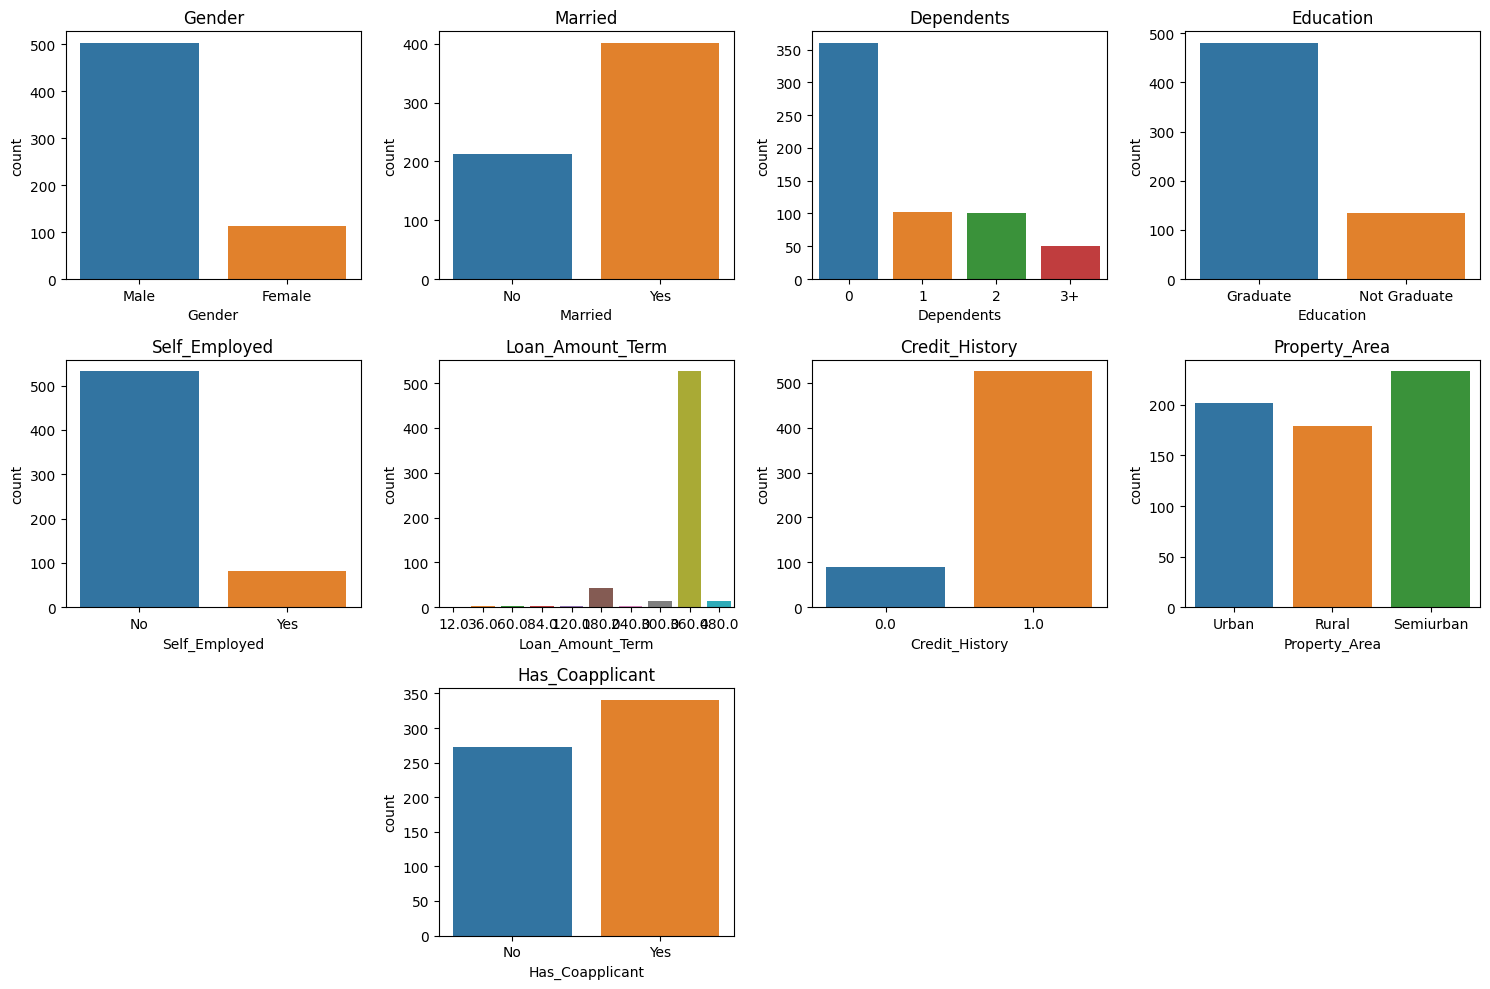

In [14]:
plt.figure(figsize=(15,10))

for i, col in enumerate(categorical_col):
    if col == "Loan_Status":
        continue
    plt.subplot(3, 4, i+1) 
    sns.countplot(data=df_trial, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

### 5.2.2. Numeric data

Univariate analysis of numeric variables helps examine the distribution of income and loan features in the dataset. This helps identify skewness, outliers, and other patterns that may affect model performance.

In [15]:
print(df_trial.describe())

       Applicant_Income  Coapplicant_Income  Loan_Amount  Total_Income  \
count        614.000000          614.000000   614.000000    614.000000   
mean        5403.459283         1621.245798   145.752443   7024.705081   
std         6109.041673         2926.248369    84.107233   6458.663872   
min          150.000000            0.000000     9.000000   1442.000000   
25%         2877.500000            0.000000   100.250000   4166.000000   
50%         3812.500000         1188.500000   128.000000   5416.500000   
75%         5795.000000         2297.250000   164.750000   7521.750000   
max        81000.000000        41667.000000   700.000000  81000.000000   

              DTI  Dept_Ratio  
count  614.000000  614.000000  
mean    51.189296   39.473446  
std     37.709429   34.358791  
min     12.090196    1.111111  
25%     35.513864   23.399791  
50%     41.443547   32.340264  
75%     52.027847   42.542445  
max    396.366667  331.550000  


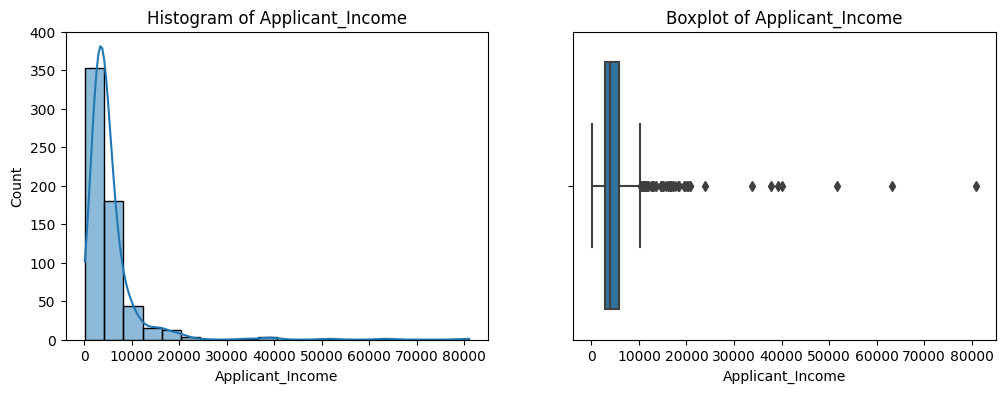

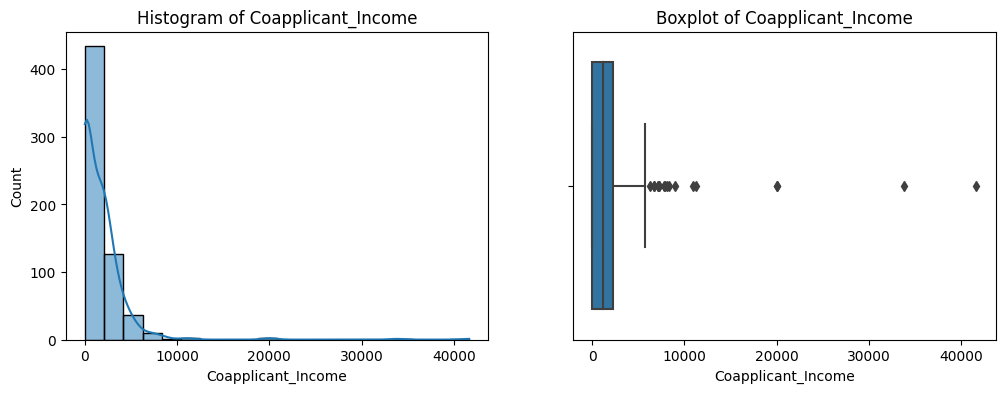

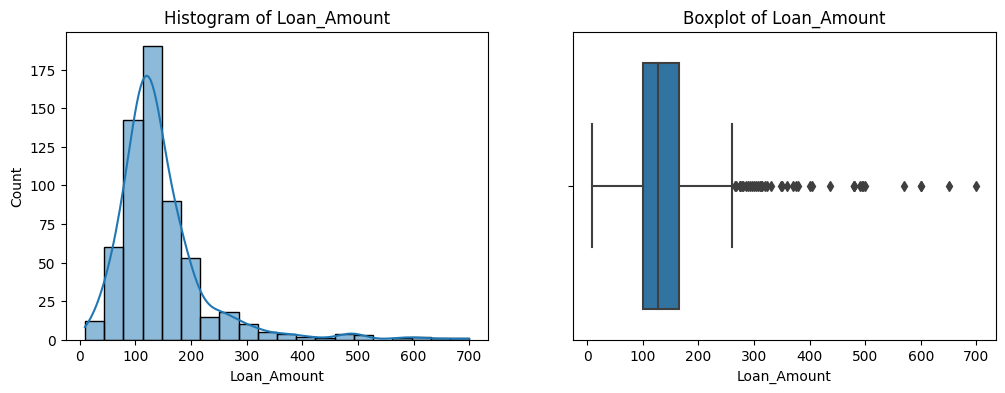

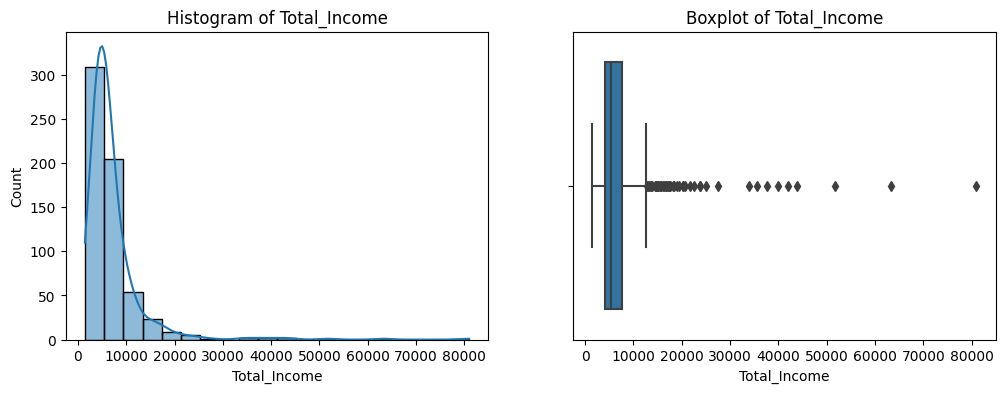

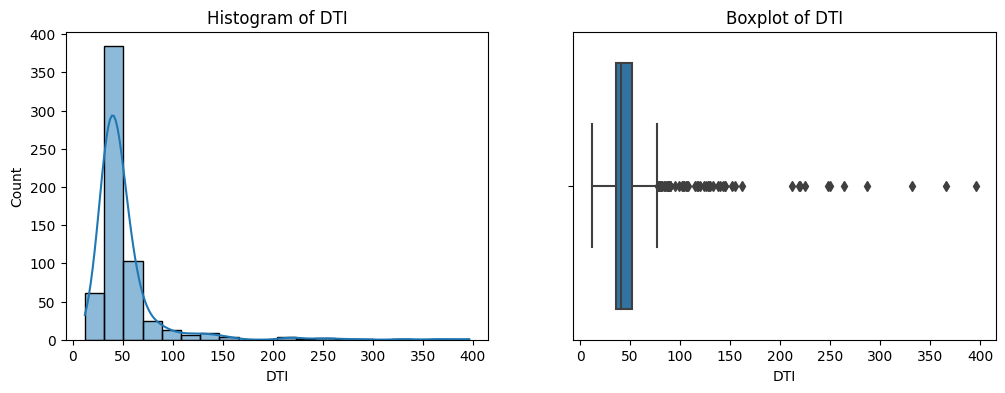

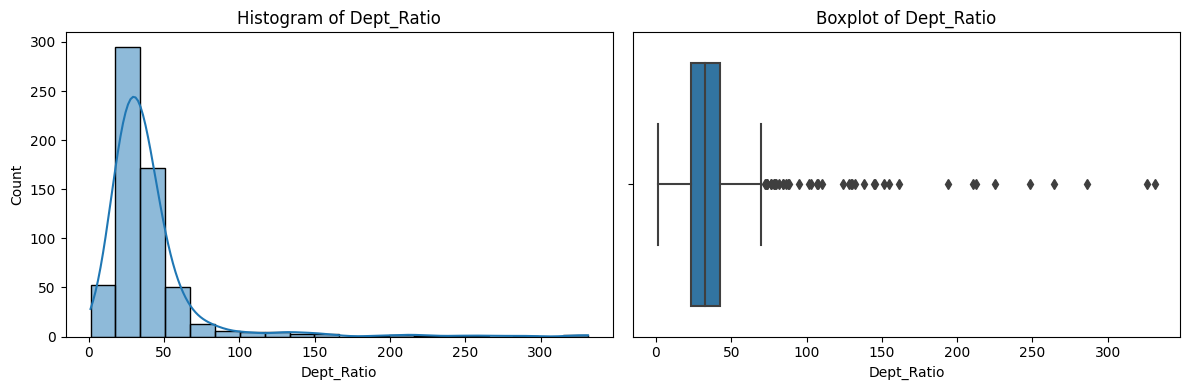

In [16]:
for i in numeric_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(df_trial[i], bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {i}")

    # Boxplot
    sns.boxplot(x=df_trial[i], ax=axes[1])
    axes[1].set_title(f"Boxplot of {i}")

plt.tight_layout()
plt.show()

In [17]:
#Calculating skewness of data determine
for i in numeric_col:
    skew = df_trial[numeric_col].skew() 
print("Skewness of numeric data:\n", skew)

Skewness of numeric data:
 Applicant_Income      6.539513
Coapplicant_Income    7.491531
Loan_Amount           2.743053
Total_Income          5.633449
DTI                   4.968467
Dept_Ratio            4.723446
dtype: float64


## 5.3 Bivariete analysis

This section examines the relationship between categorical and numeric variables and loan approval status. The goal is to identify patterns and differences between approved and rejected loan applications.

For categorical variables, we examine how different groups (e.g., marital status, education level, or property area) relate to loan approval outcomes.

For numeric variables, we analyze how financial features such as applicant income, coapplicant income, loan amount, and engineered features differ between approved and rejected loans.

These analyses help identify variables that may carry predictive information for loan approval and inform decisions for feature selection and feature engineering.

### 5.3.1. Categorical data vs Loan Status

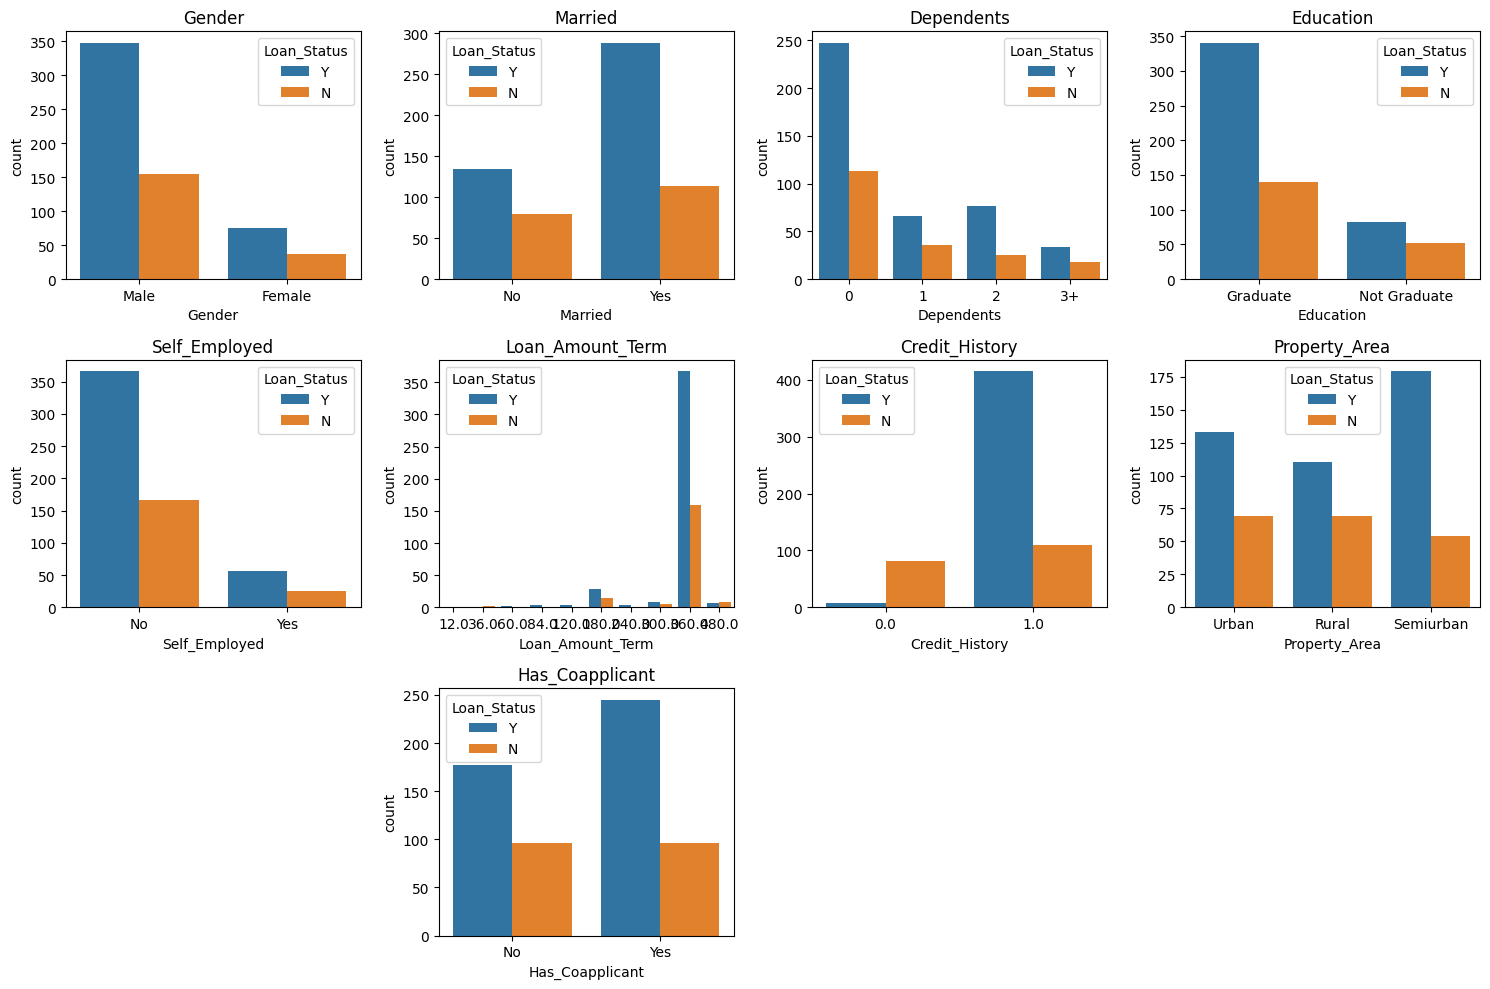

In [18]:
plt.figure(figsize=(15,10))

for i, col in enumerate(categorical_col):
    if col == "Loan_Status":
        continue
    plt.subplot(3, 4, i+1) 
    sns.countplot(data=df_trial, x=col, hue="Loan_Status")
    plt.title(col)

plt.tight_layout()
plt.show()

### 5.3.2. Numeric relationship and target analysis

Bivariate analysis of numeric variables against loan status helps identify differences in income and loan characteristics between approved and rejected loans. This helps determine which numeric features may contribute predictive power when evaluating loan approval.

<Figure size 1000x1000 with 0 Axes>

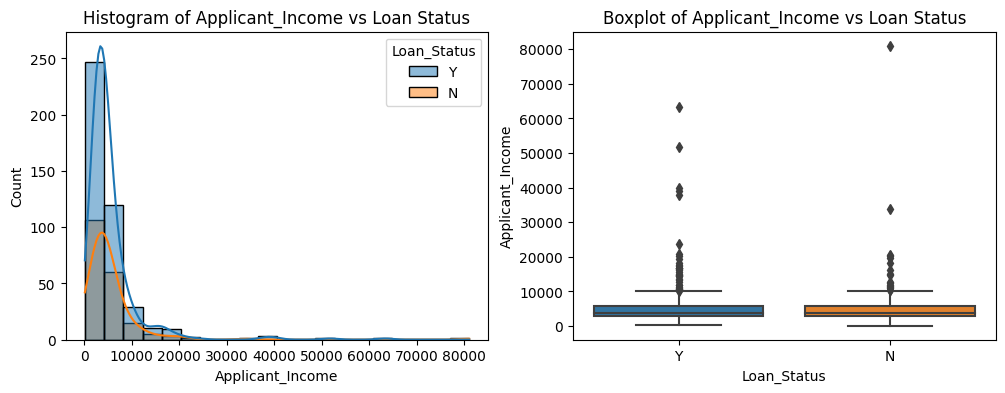

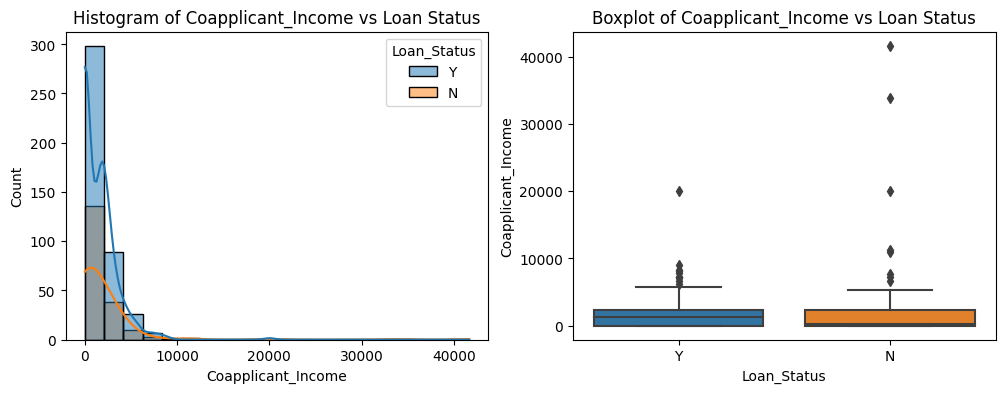

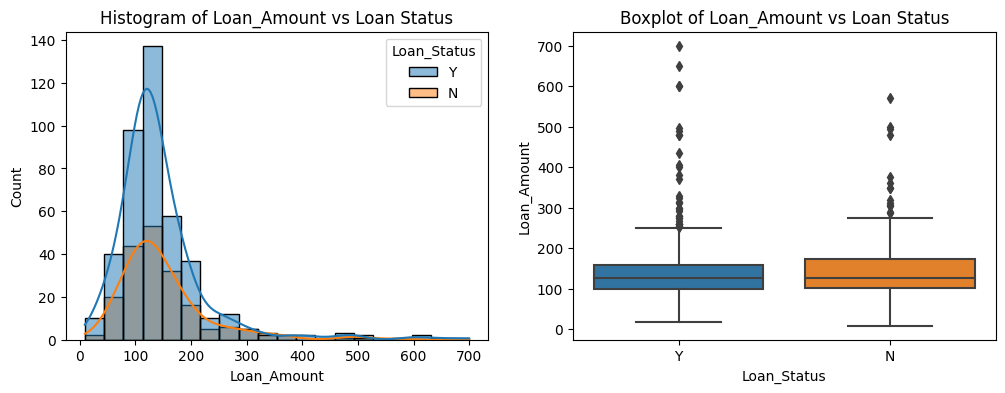

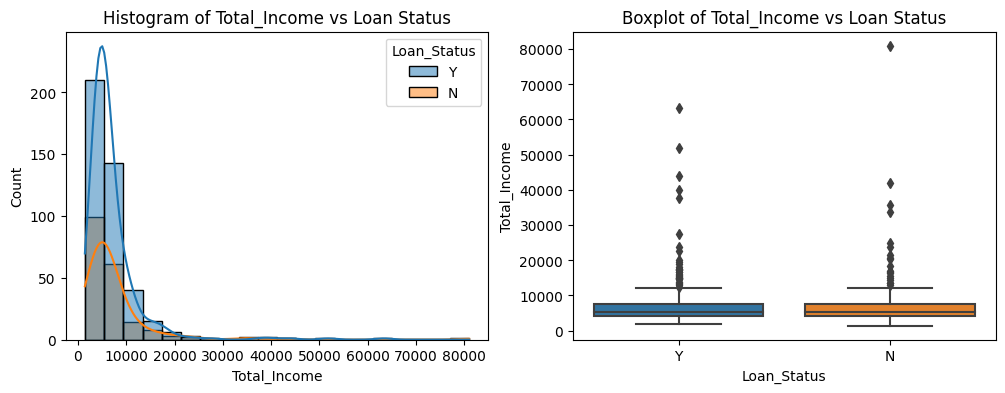

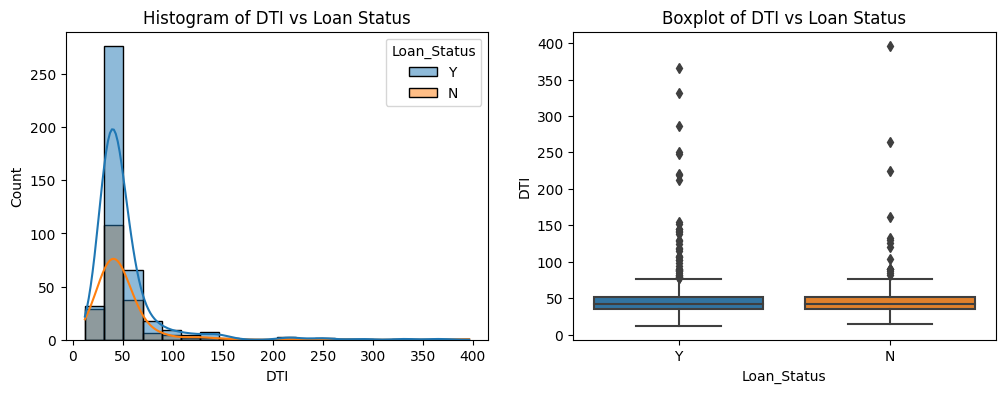

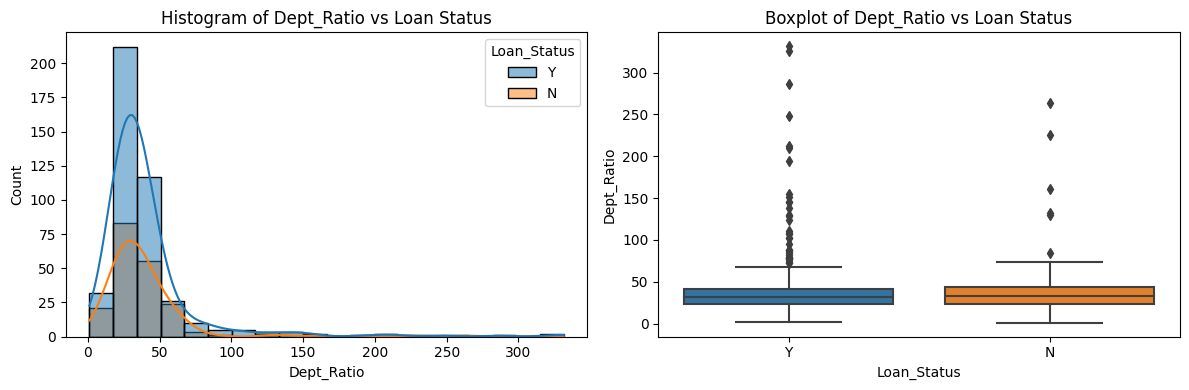

In [19]:
plt.figure(figsize=(10,10))
for i in numeric_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(data=df_trial, x=i, hue="Loan_Status", bins=20, kde=True, ax=axes[0])   
    axes[0].set_title(f"Histogram of {i} vs Loan Status")

    # Boxplot
    sns.boxplot(data=df_trial, y=i, x="Loan_Status", ax=axes[1])
    axes[1].set_title(f"Boxplot of {i} vs Loan Status")

plt.tight_layout()
plt.show()

### Section 5. Conclusion

Several important patterns can be observed:

- Majority of applicants had their loans approved (~ 69%)
- Applicants with a good credit history appear significantly more likely to receive loan approval.
- Loan_Amount and income variables exhibit strong right-skewed distributions, suggesting the presence of outliers which is expected.
- Most loans have a repayment term of 360 months.
- Certain categorical variables such as property area may influence approval rates.
- Engineered features have similar distrinutions as other features

the distrubitions of data for numeric bivariete analysis is so that loans that have approved or rejected have the same distrubitions. for boxplots we can see high incomes outliers cause loans to be rejected but higher amount of loan outliers get accepted. engineered features don't bring new insight about data 

These observations motivate the need for feature engineering and transformation in the next stage of the analysis.

# 6. Outlier detection

## 6.1. Categorical values

In [20]:
#From the visualization we could see that Loan_Amount_Term had some variance in it.
loan_amount_term_percentage = (df["Loan_Amount_Term"].value_counts()/614)*100
print("Percentage of each value in category Loan_Amount_Term:\n",loan_amount_term_percentage)

#Creating new category in Loan_Amount_Term to have values that don't have significant amount of data entries
threshold = 5
rare_terms = loan_amount_term_percentage[loan_amount_term_percentage < threshold].index
df["Loan_Amount_Term_grouped"] = df["Loan_Amount_Term"].replace(rare_terms, "Other")

Percentage of each value in category Loan_Amount_Term:
 360.0    85.667752
180.0     7.166124
480.0     2.442997
300.0     2.117264
240.0     0.651466
84.0      0.651466
120.0     0.488599
60.0      0.325733
36.0      0.325733
12.0      0.162866
Name: Loan_Amount_Term, dtype: float64


<AxesSubplot:xlabel='Loan_Amount_Term_grouped', ylabel='count'>

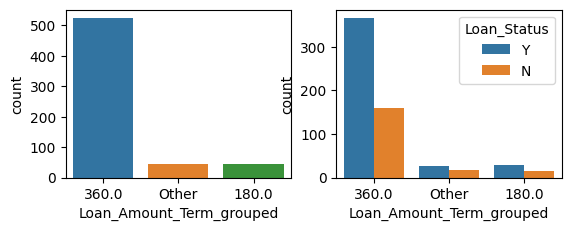

In [21]:
#New category visualized
plt.subplot(2, 2, 1)
sns.countplot(data=df, x="Loan_Amount_Term_grouped")

plt.subplot(2, 2, 2)
sns.countplot(data=df, x="Loan_Amount_Term_grouped", hue="Loan_Status")

By calculating the percentage of observations in each group, we can see that loan terms of 360 and 180 months contain the majority of entries, while other values occur very infrequently. To simplify the analysis and reduce sparsity, all remaining categories are grouped into a single "Other" category.

This grouping is performed at this stage because it is a categorical restructuring rather than a numerical transformation, so it does not affect later preprocessing steps.

After grouping the categories, it becomes clearer that there is a relationship between a 360-month loan term and loan approval, with a higher proportion of approved loans observed for this category.learly seen there is some correlation betweeen 360 month loan time and an excepted loan

## 6.2 Numeric values

From the histograms and boxplots above, we can see that several variables are right-skewed (positively skewed), particularly those related to income and loan amounts.

According to the resource referenced above (Building a Credit Score Model: Handling Missing Values and Outliers), extreme income and loan values are valid observations, as they represent individuals with unusually high financial capacity. Therefore, these values should not be removed, but their influence can be reduced by capping extreme values.

To address this, the data will be Winsorized, meaning values above the 99th percentile will be capped, and extremely low values will be capped at the 1st percentile. This reduces the influence of extreme outliers while preserving the overall structure of the data. An exception is made for Coapplicant_Income, only the 99th percentile cap will be applied. The lower bound will not be capped because many observations contain 0 values, representing applicants without a coapplicant.

These transformations will not be applied directly to the original dataset, but instead to the copy of the data prepared earlier. This prevents data leakage and allows the effect of Winsorization to be evaluated. After Winsorization, the capped values will be log-transformed to reduce skewness and improve the ability to detect remaining outliers.

The insights from this exploratory step will be used in the next notebook, where the final preprocessing decisions will be applied to the modeling dataset.

In [22]:
for i in numeric_col:
    if i == "Coapplicant_Income":
        upper = df_trial[i].quantile(0.99)
        df_trial[f"{i}_capped"] = np.where(df_trial[i] > upper, upper, df_trial[i])
        df_trial[f"{i}_log"] = np.log1p(df_trial[f"{i}_capped"])
    else:
        lower_limit = df_trial[i].quantile(0.01)
        upper_limit = df_trial[i].quantile(0.99)
        
        # Replace values directly in outlier_application_train
        df_trial[f"{i}_capped"] = np.clip(df_trial[i], lower_limit, upper_limit)
        
        #Transforming Applicant_Income and Loan_Amount
        df_trial[f"{i}_log"] = np.log1p(df_trial[f"{i}_capped"])

In [23]:
df_trial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Loan_ID                    614 non-null    string 
 1   Gender                     614 non-null    object 
 2   Married                    614 non-null    object 
 3   Dependents                 614 non-null    object 
 4   Education                  614 non-null    object 
 5   Self_Employed              614 non-null    object 
 6   Applicant_Income           614 non-null    float64
 7   Coapplicant_Income         614 non-null    float64
 8   Loan_Amount                614 non-null    float64
 9   Loan_Amount_Term           614 non-null    object 
 10  Credit_History             614 non-null    object 
 11  Property_Area              614 non-null    object 
 12  Loan_Status                614 non-null    object 
 13  Total_Income               614 non-null    float64

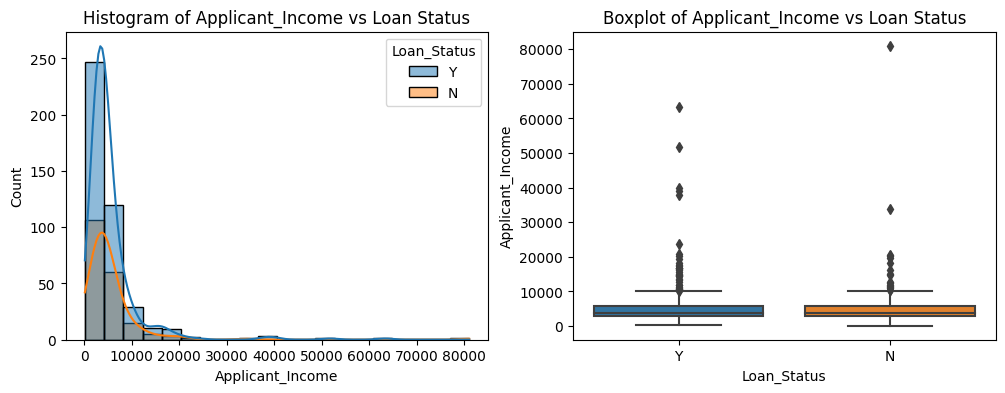

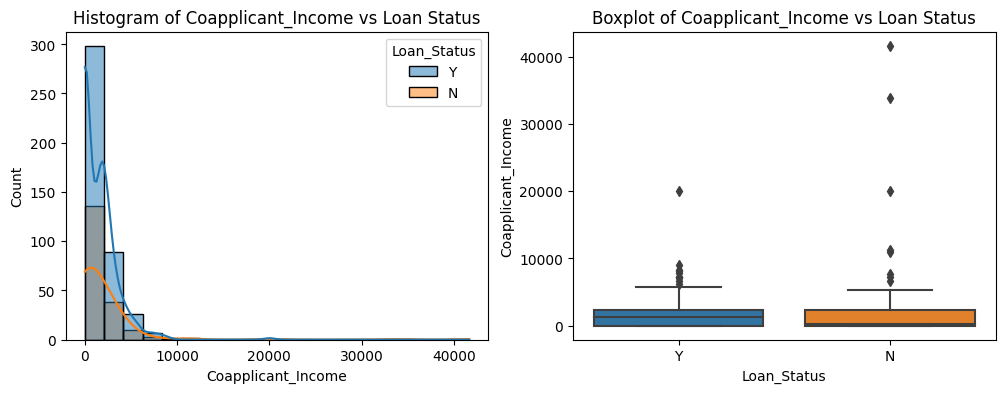

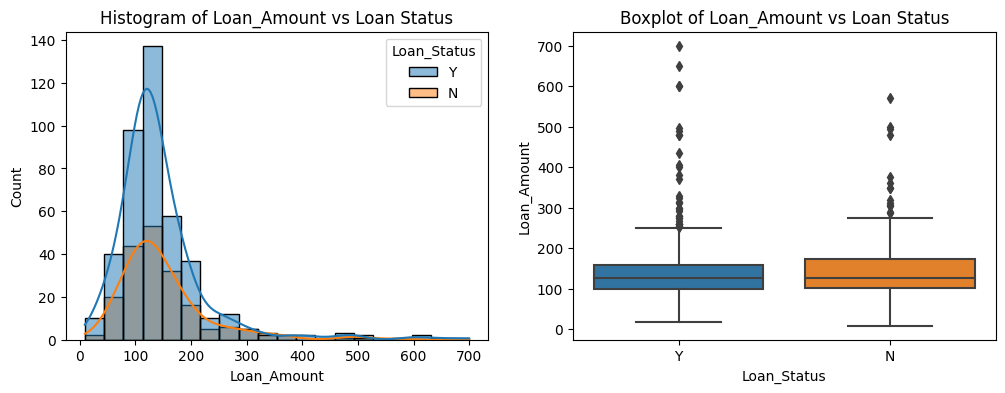

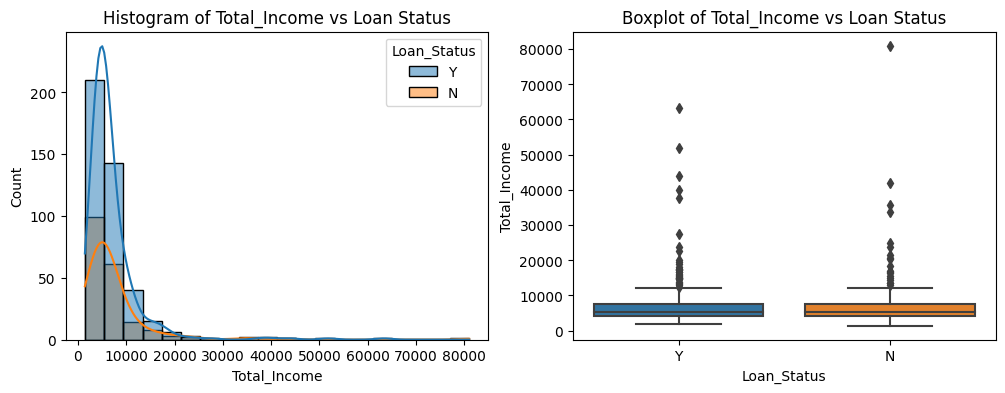

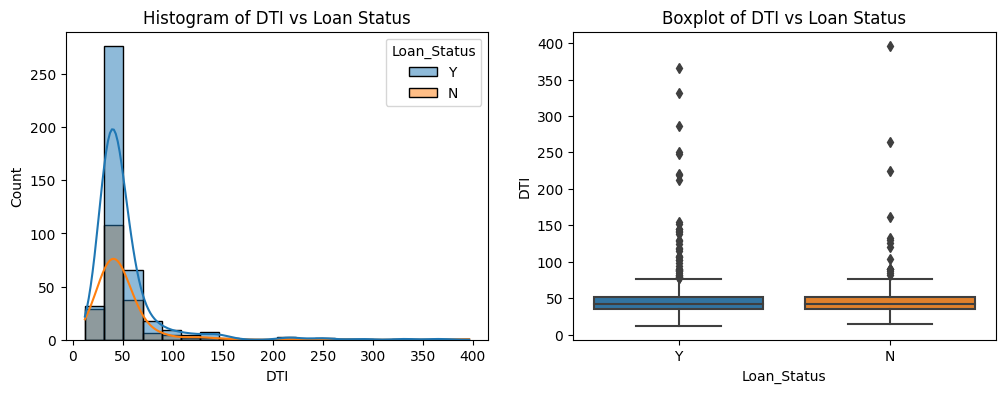

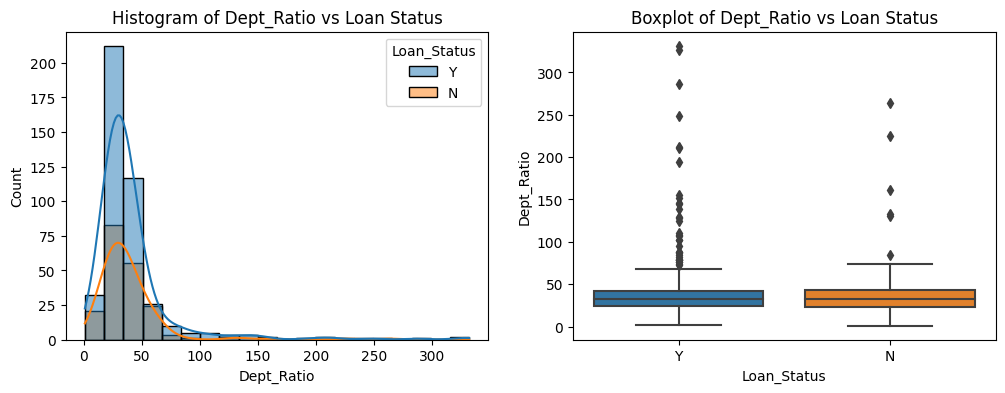

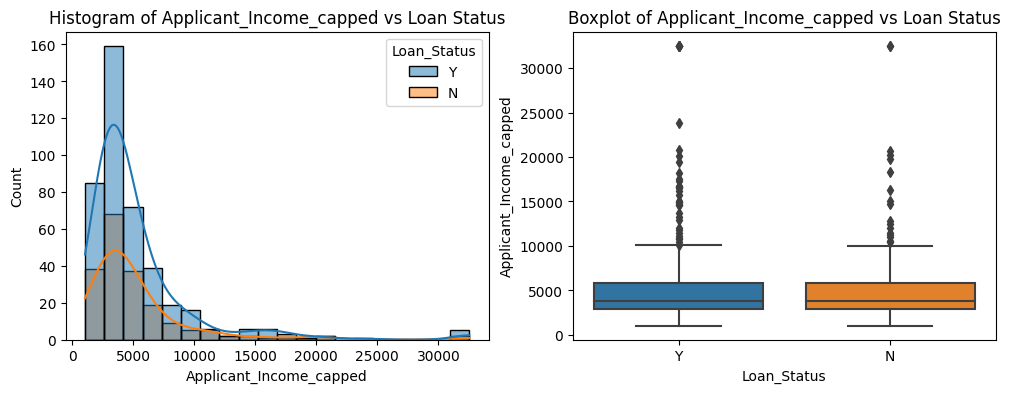

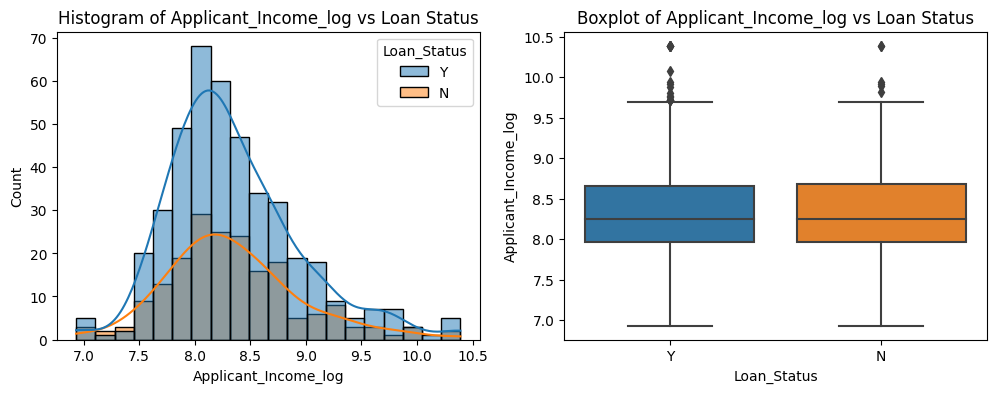

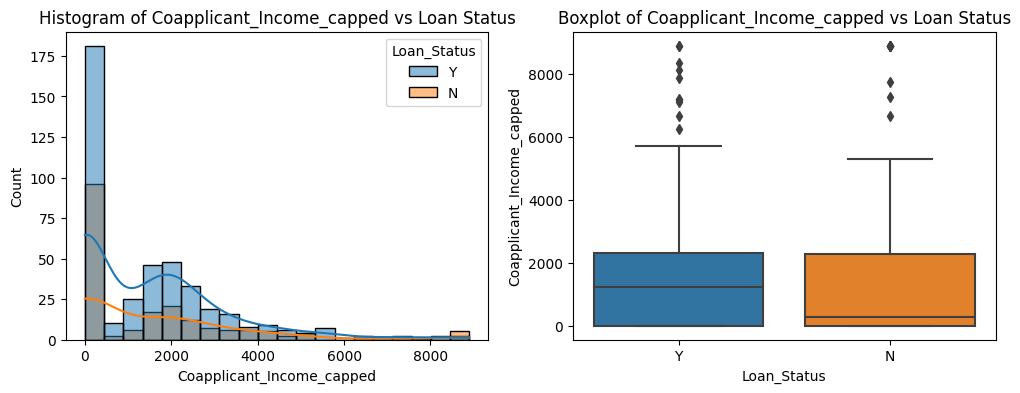

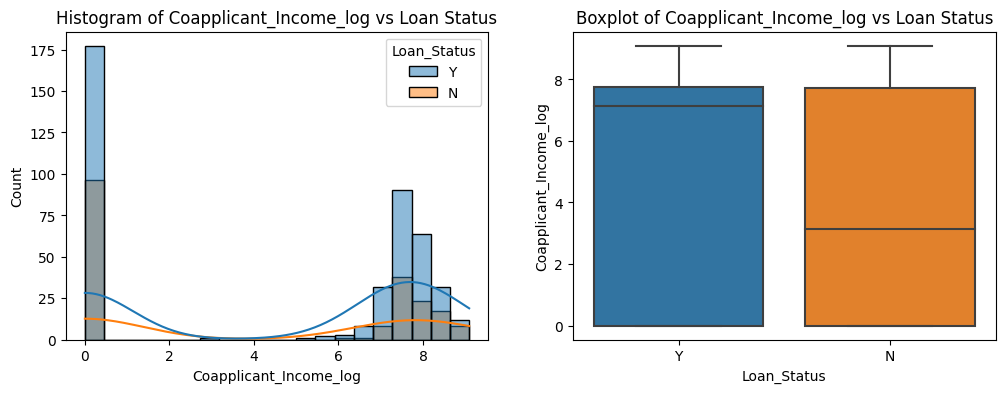

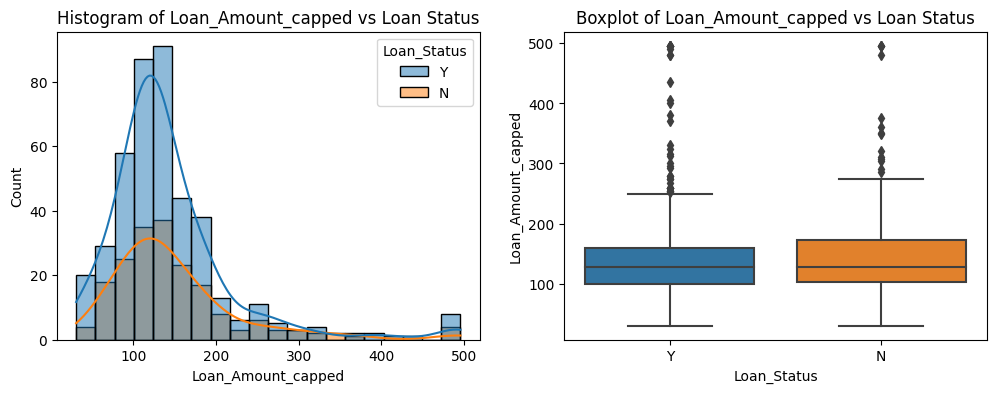

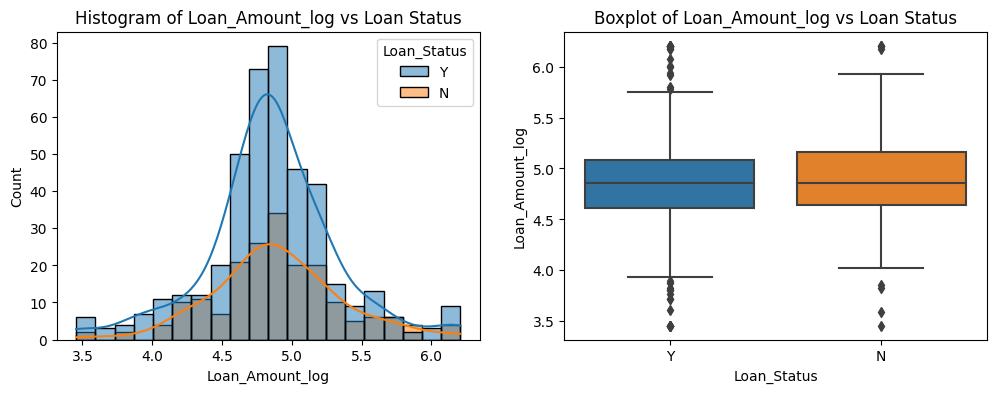

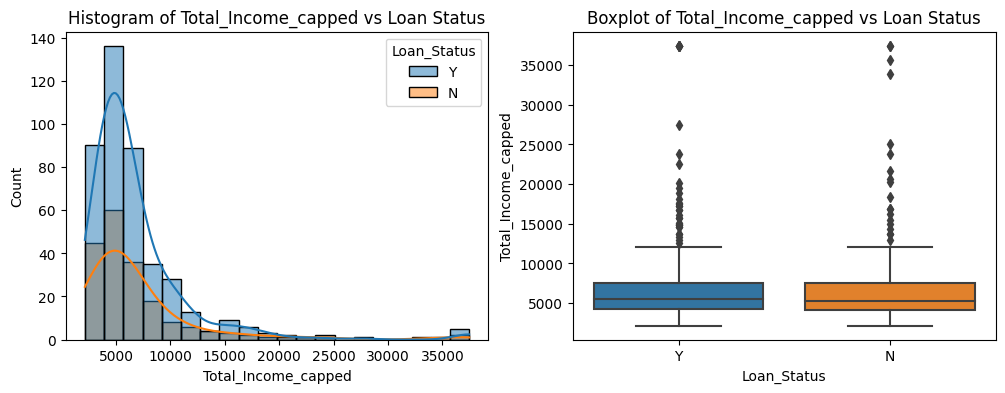

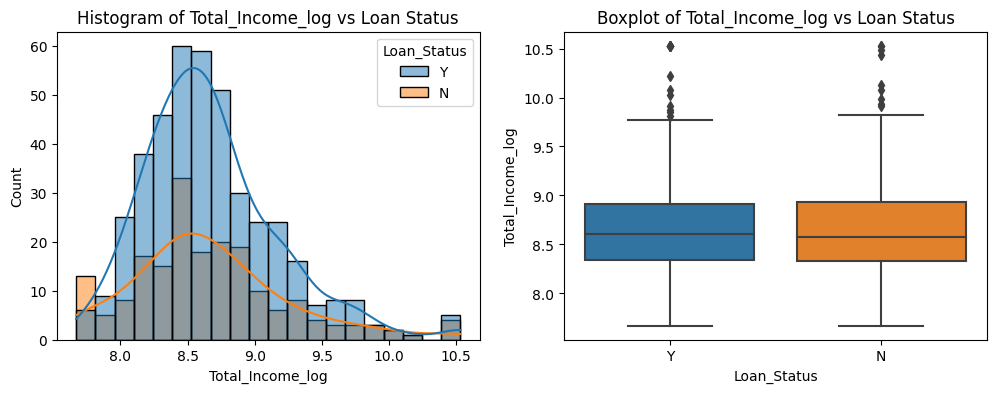

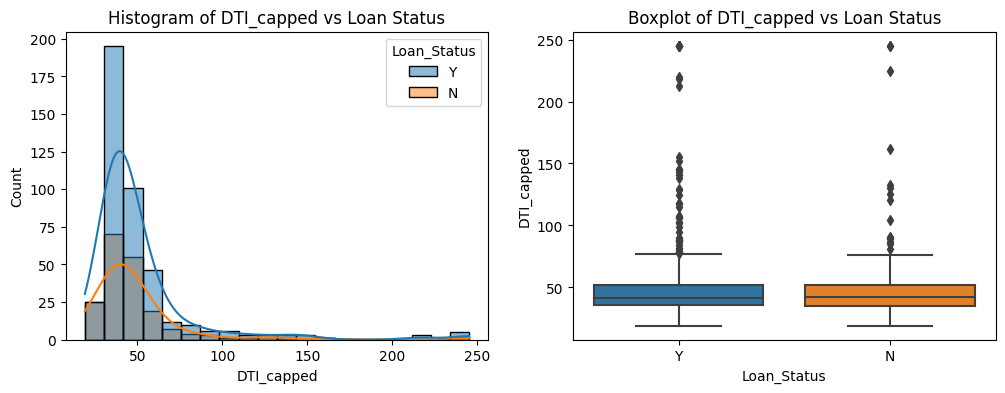

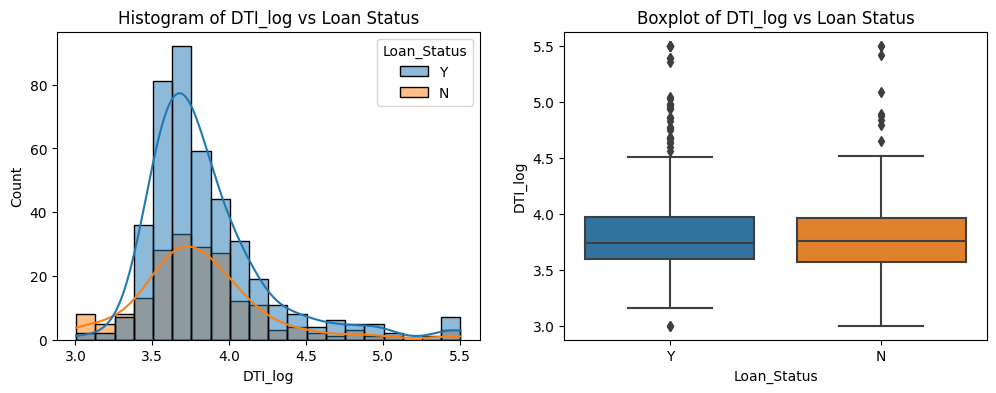

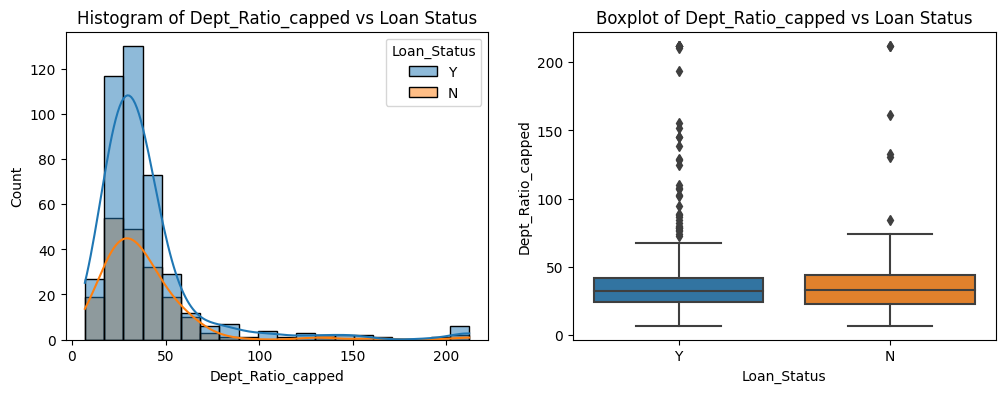

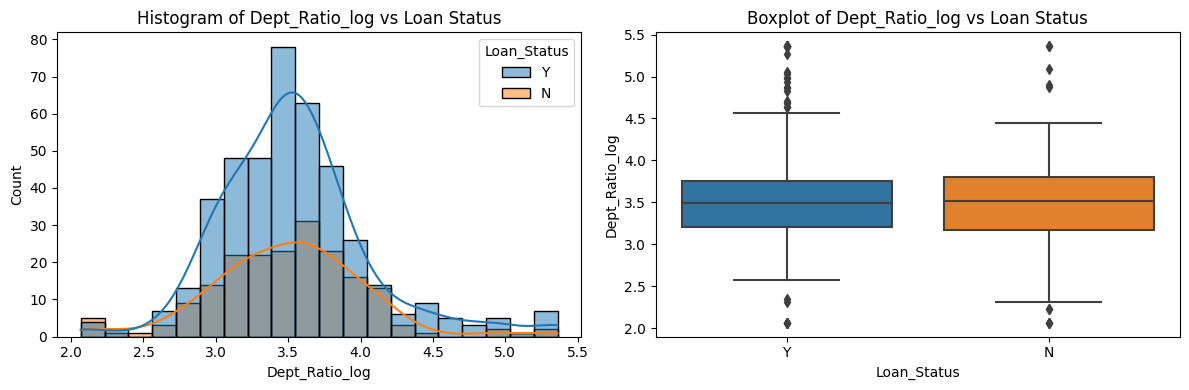

In [24]:
numeric_cols = df_trial.select_dtypes(include="number").columns.tolist()

for i in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(data=df_trial, x=i, hue="Loan_Status", bins=20, kde=True, ax=axes[0])   
    axes[0].set_title(f"Histogram of {i} vs Loan Status")

    # Boxplot
    sns.boxplot(data=df_trial, y=i, x="Loan_Status", ax=axes[1])
    axes[1].set_title(f"Boxplot of {i} vs Loan Status")

plt.tight_layout()
plt.show()
    
#Calculating skewness of data determine
for i in numeric_cols:
    skews = df_trial[numeric_cols].skew() 

In [25]:
for i in numeric_col:
    print(f"Variable: {i}")
    print(f"  Original skew: {skews.get(i, 'N/A')}")
    print(f"  Capped skew: {skews.get(f'{i}_capped', 'N/A')}")
    print(f"  Log-transformed skew: {skews.get(f'{i}_log', 'N/A')}")
    print("-" * 40)


Variable: Applicant_Income
  Original skew: 6.539513113994625
  Capped skew: 3.445069419166345
  Log-transformed skew: 0.8108853013343567
----------------------------------------
Variable: Coapplicant_Income
  Original skew: 7.491531216657306
  Capped skew: 1.6119186307370914
  Log-transformed skew: -0.18051090922586283
----------------------------------------
Variable: Loan_Amount
  Original skew: 2.743052748820892
  Capped skew: 2.2359243099148953
  Log-transformed skew: 0.05982677830589499
----------------------------------------
Variable: Total_Income
  Original skew: 5.633448514884535
  Capped skew: 3.454379521558285
  Log-transformed skew: 0.9293404301251096
----------------------------------------
Variable: DTI
  Original skew: 4.968467173798612
  Capped skew: 3.856273929467055
  Log-transformed skew: 1.6192727146713786
----------------------------------------
Variable: Dept_Ratio
  Original skew: 4.7234457772292275
  Capped skew: 3.633741891929374
  Log-transformed skew: 0.6483

The numeric data still exhibits some skew, but it is significantly reduced compared to the original values. This is expected, as most individuals have moderate incomes and loan amounts, while a few have extremely high values.

After applying Winsorization (capping at the 1st and 99th percentiles) and log transformations, most numeric variables show substantially reduced skewness.

Applicant_Income, Loan_Amount, and Total_Income are now closer to symmetric, making them more suitable for modeling.

Ratios such as DTI and Dept_Ratio still show mild skew, but these levels are generally acceptable for most modeling techniques.

## 7. Saving cleaned data for next steps

In [26]:
df.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\cleaned_data\clean_data", index=False)

# 8. Conclusions

In this notebook, we performed exploratory data analysis (EDA) and initial preprocessing on the loan dataset to prepare it for modeling. The key findings and steps are summarized below:

**Data Overview and Missing Values**

- The dataset contains 14 features, with missing values ranging from 0.5% to 8% per feature.

- Missingness was analyzed and determined to be largely MCAR (Missing Completely at Random).

- Simple imputation was applied: median for numeric variables and mode for categorical variables.

- No rows were dropped to preserve data, though Credit_History, with the most missing values (~8%), may affect model outcomes and should be considered in future steps.

**Feature Engineering and Transformations**

- New features were created to enhance modeling:

  - Total_Income = Applicant + Coapplicant income

  - DTI (Debt-to-Income ratio)

  - Debt_Ratio (Loan-to-Applicant income ratio)

  - Has_Coapplicant (binary indicator of coapplicant presence)

- These features capture household repayment capacity and financial pressure, which are important for loan approval prediction.

**Outlier Handling and Skewness Reduction**

- Numeric features such as income and loan amounts showed extreme positive skew.

- Winsorization was applied to cap the 1st and 99th percentiles, and log transformations were used to reduce skewness.

- After these transformations, most features are now closer to symmetric, making them suitable for modeling, while ratios like DTI and Debt_Ratio show mild skew, acceptable for most algorithms.

**Categorical and Bivariate Analysis**

- Categorical variables were analyzed to identify rare categories and imbalances.

- Bivariate analysis with the target variable (loan approval) helped highlight which features may carry predictive information, guiding feature selection in future modeling.

**Next Steps**

- The processed data and engineered features will be used in Notebook 2 for modeling.

- Original income and loan features will be retained until modeling, but redundant features may be dropped later.

- Further handling of skewed variables, outliers, and feature importance evaluation will be conducted during model development.